<a href="https://colab.research.google.com/github/LaylaVenancio/python-olist-logistic-analysis/blob/main/de_Tech_Challenge_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tech Challenge

##Importação

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
url1 = "/content/drive/MyDrive/Colab Notebooks/Dados/Tech Challenge 1/olist_order_items_dataset.csv"
url2 = "/content/drive/MyDrive/Colab Notebooks/Dados/Tech Challenge 1/olist_orders_dataset.csv"
url3 = "/content/drive/MyDrive/Colab Notebooks/Dados/Tech Challenge 1/olist_customers_dataset.csv"
url4 = "/content/drive/MyDrive/Colab Notebooks/Dados/Tech Challenge 1/olist_order_reviews_dataset.csv"
url5 = "/content/drive/MyDrive/Colab Notebooks/Dados/Tech Challenge 1/olist_products_dataset.csv"
url6 = "/content/drive/MyDrive/Colab Notebooks/Dados/Tech Challenge 1/olist_sellers_dataset.csv"
url7 = "/content/drive/MyDrive/Colab Notebooks/Dados/Tech Challenge 1/olist_geolocation_dataset.csv"

olist_order_items_dataset = pd.read_csv(url1,sep=',')
olist_orders_dataset = pd.read_csv(url2,sep=",")
olist_customers_dataset = pd.read_csv(url3, sep = ",")
olist_order_reviews_dataset = pd.read_csv(url4, sep = ",")
olist_products_dataset = pd.read_csv(url5, sep = ",")
olist_sellers_dataset = pd.read_csv(url6, sep = ",")
olist_geolocation_dataset = pd.read_csv(url7, sep = ",")

##Limpeza dos dados

###olist_order_items_dataset

In [4]:
#Shape diz o número de (linhas,colunas)
olist_order_items_dataset.shape

(112650, 7)

In [5]:
#head() traz as primeiras 5 linhas
olist_order_items_dataset.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
#Traz o tipo das colunas
olist_order_items_dataset.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,object
price,float64
freight_value,float64


In [7]:
# Convertendo para datetime
olist_order_items_dataset['shipping_limit_date'] = pd.to_datetime(olist_order_items_dataset['shipping_limit_date'])

# Verificando se mudou
olist_order_items_dataset.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,datetime64[ns]
price,float64
freight_value,float64


In [8]:
#Verifica a existência de nulos
olist_order_items_dataset.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [9]:
#Verifica se existem linhas iguais
olist_order_items_dataset.duplicated().sum()

np.int64(0)

###olist_orders_dataset

In [10]:
olist_orders_dataset.shape

(99441, 8)

In [11]:
olist_orders_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [12]:
olist_orders_dataset.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object


In [13]:
#Colunas que precisam ser convertidas
ColunasData = ['order_purchase_timestamp',
               'order_approved_at',
               'order_delivered_carrier_date',
               'order_delivered_customer_date',
               'order_estimated_delivery_date']

# Convertendo para datetime
olist_orders_dataset[ColunasData] = olist_orders_dataset[ColunasData].apply(pd.to_datetime)

# Verificando se mudou
olist_orders_dataset.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [14]:
#Verifica a existência de nulos
olist_orders_dataset.isnull().sum()

#Não vou excluir os nulos, porque nesse caso, eles fazem sentido. Por exemplo, os nulos em "Order_approvved_at" indicam pedidos que ainda não foram aprovados

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [15]:
olist_orders_dataset.duplicated().sum()

np.int64(0)

###olist_customers_dataset

In [16]:
olist_customers_dataset.shape

(99441, 5)

In [17]:
olist_customers_dataset.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [18]:
olist_customers_dataset.dtypes

,0
customer_id,object
customer_unique_id,object
customer_zip_code_prefix,int64
customer_city,object
customer_state,object


###olist_order_reviews_dataset

In [19]:
olist_order_reviews_dataset.shape

(99224, 7)

In [20]:
olist_order_reviews_dataset.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [21]:
#Traz o tipo das colunas
olist_order_reviews_dataset.dtypes

,0
review_id,object
order_id,object
review_score,int64
review_comment_title,object
review_comment_message,object
review_creation_date,object
review_answer_timestamp,object


In [22]:
#Colunas que precisam ser convertidas
ColunasData_Review = ["review_creation_date",
                      "review_answer_timestamp"]


# Convertendo para datetime
olist_order_reviews_dataset[ColunasData_Review] = olist_order_reviews_dataset[ColunasData_Review].apply(pd.to_datetime)

# Verificando se mudou
olist_order_reviews_dataset.dtypes

,0
review_id,object
order_id,object
review_score,int64
review_comment_title,object
review_comment_message,object
review_creation_date,datetime64[ns]
review_answer_timestamp,datetime64[ns]


In [23]:
#Verifica a existência de nulos
olist_order_reviews_dataset.isnull().sum()

#Não vou excluir os nulos, porque nesse caso, eles fazem sentido. Não é obrigatório deixar uma mensagem no título / comentário

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [24]:
olist_order_reviews_dataset.duplicated().sum()

np.int64(0)

###olist_product_dataset

In [25]:
olist_products_dataset.shape

(32951, 9)

In [26]:
olist_products_dataset.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [27]:
olist_products_dataset.dtypes

,0
product_id,object
product_category_name,object
product_name_lenght,float64
product_description_lenght,float64
product_photos_qty,float64
product_weight_g,float64
product_length_cm,float64
product_height_cm,float64
product_width_cm,float64


In [28]:
olist_products_dataset.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [29]:
#Substitui os nulos por "Sem informação"
olist_products_dataset = olist_products_dataset.fillna("Sem Informação")

#checa se funcionou
olist_products_dataset.isnull().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [30]:
olist_products_dataset.duplicated().sum()

np.int64(0)

In [31]:
olist_customers_dataset.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


###olist_sellers_dataset

In [32]:
olist_sellers_dataset.shape

(3095, 4)

In [33]:
olist_sellers_dataset.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [34]:
olist_sellers_dataset.dtypes

,0
seller_id,object
seller_zip_code_prefix,int64
seller_city,object
seller_state,object


In [35]:
olist_sellers_dataset.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [36]:
olist_sellers_dataset.duplicated().sum()

np.int64(0)

###olist_geolocation_dataset

In [37]:
olist_geolocation_dataset.shape

(1000163, 5)

In [38]:
olist_geolocation_dataset.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [39]:
olist_geolocation_dataset.dtypes

,0
geolocation_zip_code_prefix,int64
geolocation_lat,float64
geolocation_lng,float64
geolocation_city,object
geolocation_state,object


In [40]:
olist_geolocation_dataset.isnull().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [41]:
olist_geolocation_dataset.duplicated().sum()

np.int64(261831)

In [42]:
#Remover duplicadas
olist_geolocation_dataset.drop_duplicates(inplace=True)

In [43]:
#Ajusta a tabela para 1 registro por CEP, com a média da latitude e longitude, e o primeiro registo de cidade/Estado
olist_geolocation_dataset = olist_geolocation_dataset.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

##Preparação dos Dados

###Orders_delivered

Tabela com granularidade de pedidos entregues, reunindo todas as informações relevantes para a análise exploratória

In [44]:
#Agregar olist_order_items_dataset por pedido
olist_order_items_dataset = olist_order_items_dataset.groupby('order_id').agg({
    'seller_id': 'first',
    'order_item_id': 'max',
    'shipping_limit_date': 'first',
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()

In [45]:
#join com olist_orders_dataset
orders_delivered = pd.merge(olist_order_items_dataset,olist_orders_dataset,on='order_id',how='right')

#filtrar apenas os pedidos entregues
orders_delivered = orders_delivered[orders_delivered['order_status'] == 'delivered']

#criação de variável - seller_shipping_days
orders_delivered['seller_shipping_days'] = (
    orders_delivered['order_delivered_carrier_date'] -
    orders_delivered['shipping_limit_date']
).dt.days

#Criação de variável - seller_shipping_status

orders_delivered['seller_shipping_status'] = np.where(
    orders_delivered['seller_shipping_days'] > 0,
    "Late",
    np.where(orders_delivered['seller_shipping_days'] < 0, "Early", "On Time")
)

#Criação de variável - delivery_vs_estimated_days
orders_delivered['delivery_vs_estimated_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_estimated_delivery_date']
).dt.days

#Criação de variável - delivery_vs_estimated_status
orders_delivered['delivery_vs_estimated_status'] = np.where(
    orders_delivered['delivery_vs_estimated_days'] > 0,
    "Late",
    np.where(orders_delivered['delivery_vs_estimated_days'] < 0, "Early", "On Time"))



In [46]:
#join com olist_sellers_dataset

orders_delivered = pd.merge(orders_delivered,olist_sellers_dataset, on = 'seller_id', how = 'left')

#join com olist_geolocation_dataset
orders_delivered = pd.merge(
    orders_delivered,
    olist_geolocation_dataset[['geolocation_zip_code_prefix','geolocation_lat', 'geolocation_lng']].rename(columns={
        'geolocation_lat': 'seller_geolocation_lat',
        'geolocation_lng': 'seller_geolocation_lng'
    }),
    left_on= 'seller_zip_code_prefix',
    right_on = 'geolocation_zip_code_prefix',
    how = 'left').drop(columns=['geolocation_zip_code_prefix', "seller_city"])

In [47]:
#join com olist_customer_dataset

orders_delivered = pd.merge(orders_delivered,olist_customers_dataset, on = 'customer_id', how = 'left')

#join com olist_geolocation_dataset
orders_delivered = pd.merge(
    orders_delivered,
    olist_geolocation_dataset[['geolocation_zip_code_prefix','geolocation_lat', 'geolocation_lng']].rename(columns={
        'geolocation_lat': 'customer_geolocation_lat',
        'geolocation_lng': 'customer_geolocation_lng'
    }),
    left_on= 'customer_zip_code_prefix',
    right_on = 'geolocation_zip_code_prefix',
    how = 'left').drop(columns=['geolocation_zip_code_prefix', 'customer_city'])


In [48]:
#Criação de variável - distance_km
# A definição da função
def calcular_distancia_haversine(df):
    # Tudo aqui embaixo precisa estar indentado (com recuo)
    lat1, lon1, lat2, lon2 = map(np.radians, [
        df['customer_geolocation_lat'],
        df['customer_geolocation_lng'],
        df['seller_geolocation_lat'],
        df['seller_geolocation_lng']
    ])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c

# Criando a coluna:
orders_delivered['distance_km'] = calcular_distancia_haversine(orders_delivered)



In [49]:
#agregação de olist_order_reviews_dataset
olist_order_reviews_dataset = olist_order_reviews_dataset.groupby('order_id').agg({
    'review_answer_timestamp': 'last',
    'review_score': 'last'
}).reset_index()

#join com orders_delivered
orders_delivered = pd.merge(
    orders_delivered,
    olist_order_reviews_dataset,
    on = "order_id",
    how = 'left'
)

In [50]:
#Limpeza da base
orders_delivered.isnull().sum()

,0
order_id,0
seller_id,0
order_item_id,0
shipping_limit_date,0
price,0
freight_value,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14


In [51]:
#Colunas a serem excluídas
orders_delivered = orders_delivered[orders_delivered['distance_km'] > 0].copy()

#Check
orders_delivered.isnull().sum()

,0
order_id,0
seller_id,0
order_item_id,0
shipping_limit_date,0
price,0
freight_value,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14


In [52]:
#Arredondar distância
orders_delivered['distance_km'] = orders_delivered['distance_km'].round(2)

In [53]:
# Definição das regiões
mapeamento_regioes = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

# criação do dataset com a coluna região
orders_delivered['Customer_Region'] = orders_delivered['customer_state'].map(mapeamento_regioes)

orders_delivered.head()


,order_id,seller_id,order_item_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,...,seller_geolocation_lng,customer_unique_id,customer_zip_code_prefix,customer_state,customer_geolocation_lat,customer_geolocation_lng,distance_km,review_answer_timestamp,review_score,Customer_Region
0,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,1.0,2017-10-06 11:07:15,29.99,8.72,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,...,-46.444311,7c396fd4830fd04220f754e42b4e5bff,3149,SP,-23.577482,-46.587077,18.54,2017-10-12 03:43:48,4.0,Sudeste
1,53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,1.0,2018-07-30 03:24:27,118.70,22.76,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,...,-43.980818,af07308b275d755c9edb36a90c618231,47813,BA,-12.186877,-44.540232,849.52,2018-08-08 18:37:50,4.0,Nordeste
2,47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,1.0,2018-08-13 08:55:23,159.90,19.22,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,...,-48.229588,3a653a41f6f9fc3d2a113cf8398680e8,75265,GO,-16.745150,-48.514783,514.41,2018-08-22 19:07:58,5.0,Centro-Oeste
3,949d5b44dbf5de918fe9c16f97b45f8a,66922902710d126a0e7d26b0e3805106,1.0,2017-11-23 19:45:59,45.00,27.20,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,...,-43.923241,7c142cf63193a1473d2e66489a9ae977,59296,RN,-5.774002,-35.270976,1822.13,2017-12-05 19:21:58,5.0,Nordeste
4,ad21c59c0840e6cb83a9ceb5573f8159,2c9e548be18521d1c43cde1c582c6de8,1.0,2018-02-19 20:31:37,19.90,8.72,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,...,-46.262148,72632f0f9dd73dfee390c9b22eb56dd6,9195,SP,-23.676257,-46.514580,29.77,2018-02-18 13:02:51,5.0,Sudeste


##Análise Exploratória

### 1. A eficiência logística impacta na satisfação do cliente? Ou seja, pedidos atrasados são pior avaliados?

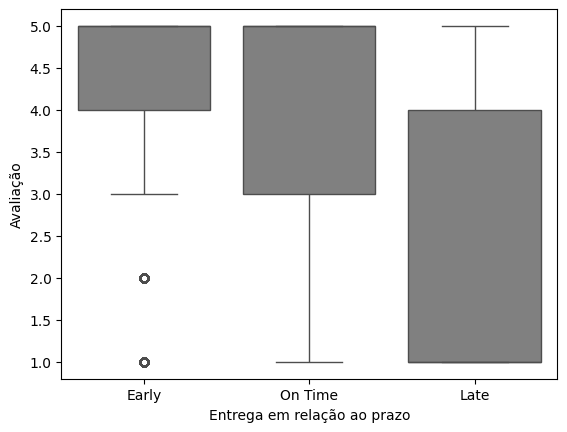

In [54]:
hipotese1 = orders_delivered[['review_score', 'delivery_vs_estimated_status']]

ax = sns.boxplot(data=hipotese1,
            x = 'delivery_vs_estimated_status',
            y = 'review_score',
            order = ['Early', 'On Time', 'Late'],
            color = 'gray'
            )

ax.set(
    ylabel = 'Avaliação',
    xlabel = 'Entrega em relação ao prazo'
)

plt.show()

In [55]:
# Em números
estatisticas = hipotese1.groupby('delivery_vs_estimated_status')['review_score'].describe()
estatisticas

,count,mean,std,min,25%,50%,75%,max
delivery_vs_estimated_status,,,,,,,,
Early,87716.0,4.293607,1.147784,1.0,4.0,5.0,5.0,5.0
Late,6336.0,2.270518,1.570462,1.0,1.0,1.0,4.0,5.0
On Time,1281.0,4.045277,1.247301,1.0,3.0,5.0,5.0,5.0


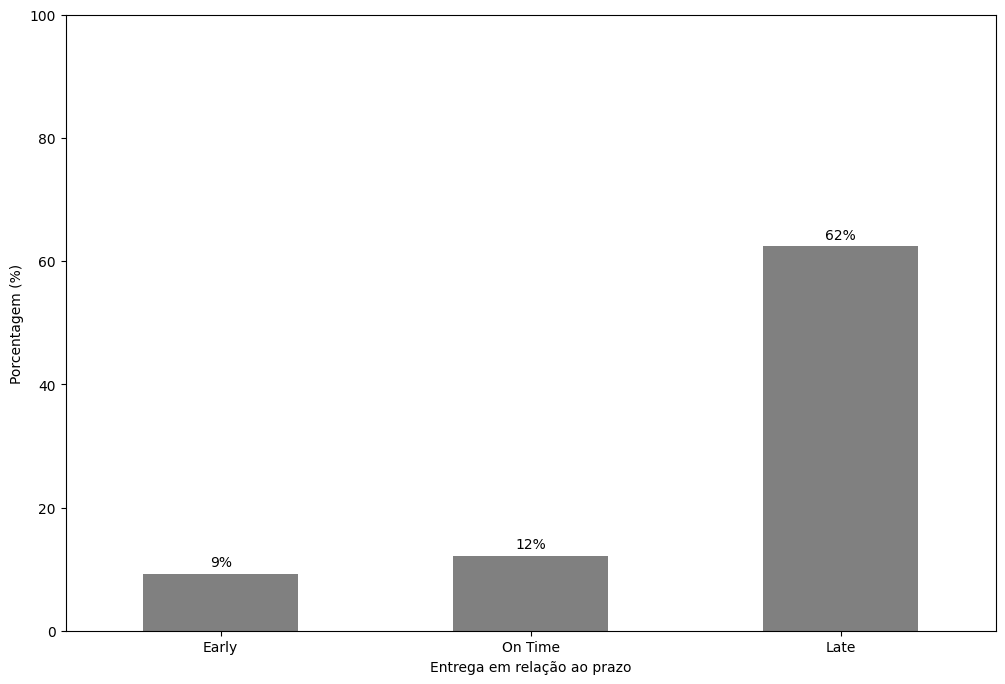

In [56]:
# % avaliações <= 2 por status de entrega
tabela_final = hipotese1.groupby('delivery_vs_estimated_status').agg(
    total_pedidos=('review_score', 'count'),
    avaliacoes_baixas=('review_score', lambda x: (x <= 2).sum())
).reset_index()

# Calculamos a porcentagem e ordenando
tabela_final['%_baixas'] = (tabela_final['avaliacoes_baixas'] / tabela_final['total_pedidos']) * 100
tabela_final = tabela_final.sort_values(by='%_baixas', ascending=True)

# plotando
ax = tabela_final[['delivery_vs_estimated_status','%_baixas']].plot(
    kind = 'bar',
    x = 'delivery_vs_estimated_status',
    y = '%_baixas',
    color = 'gray',
    grid = False,
    figsize = (12, 8),
    legend = False
)
plt.ylim(0, 100)

# personalizando
ax.bar_label(ax.containers[0], fmt='%.0f%%', padding=3)
plt.xticks(rotation=0)
plt.ylabel('Porcentagem (%)')
plt.xlabel('Entrega em relação ao prazo')

plt.show()

### 2. % de atrasados por distância entre vendedor e comprador

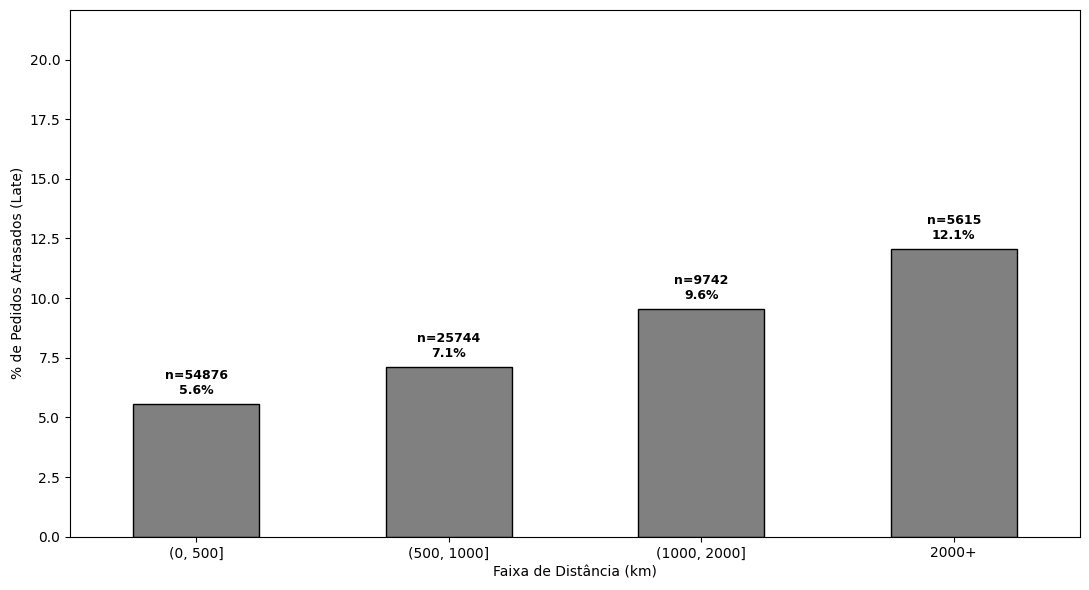

In [57]:
# Preparando o dataset
hipotese2 = orders_delivered[['distance_km', 'delivery_vs_estimated_status']].copy()
hipotese2['dist_bin'] = pd.cut(hipotese2['distance_km'], bins=[0, 500, 1000, 2000, float('inf')], labels=['(0, 500]', '(500, 1000]', '(1000, 2000]', '2000+'])
resumo = hipotese2.groupby('dist_bin', observed=False)['delivery_vs_estimated_status'].agg(
    total_pedidos='count',
    porcentagem_atraso=lambda x: (x == 'Late').mean() * 100
)

# Plotando
plt.figure(figsize=(11, 6))
ax = resumo['porcentagem_atraso'].plot(kind='bar', color='gray', edgecolor='black')

# Personalizando
for i, p in enumerate(ax.patches):
    n_absoluto = resumo['total_pedidos'].iloc[i]
    percentual = p.get_height()
    label_texto = f'n={int(n_absoluto)}\n{percentual:.1f}%'
    ax.annotate(label_texto,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 15),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold')

plt.ylabel('% de Pedidos Atrasados (Late)')
plt.xlabel('Faixa de Distância (km)')
plt.xticks(rotation=0)
plt.ylim(0, resumo['porcentagem_atraso'].max() + 10)

plt.tight_layout()
plt.show()

###3. Atrasos por região do comprador

In [58]:
# criação do dataset
hipotese3 = orders_delivered[['Customer_Region', 'delivery_vs_estimated_status']].copy()

# Tabela de frequências
hipotese3 = pd.crosstab(hipotese3['Customer_Region'], hipotese3['delivery_vs_estimated_status']).reset_index()
colunas_status = ['Early', 'Late', 'On Time']
hipotese3['total_pedidos'] = hipotese3[colunas_status].sum(axis=1)
hipotese3['porcentagem_atraso'] = (hipotese3['Late'] / hipotese3['total_pedidos']) * 100

#  Ordenação
hipotese3 = hipotese3.sort_values('porcentagem_atraso', ascending=False)
hipotese3 = hipotese3.round(1)
hipotese3 = hipotese3.reset_index(drop=True)
hipotese3.columns.name = None

hipotese3[['Customer_Region','total_pedidos','Late','porcentagem_atraso']]

,Customer_Region,total_pedidos,Late,porcentagem_atraso
0,Nordeste,8996,1141,12.7
1,Norte,1788,154,8.6
2,Centro-Oeste,5438,358,6.6
3,Sudeste,66000,4030,6.1
4,Sul,13755,806,5.9


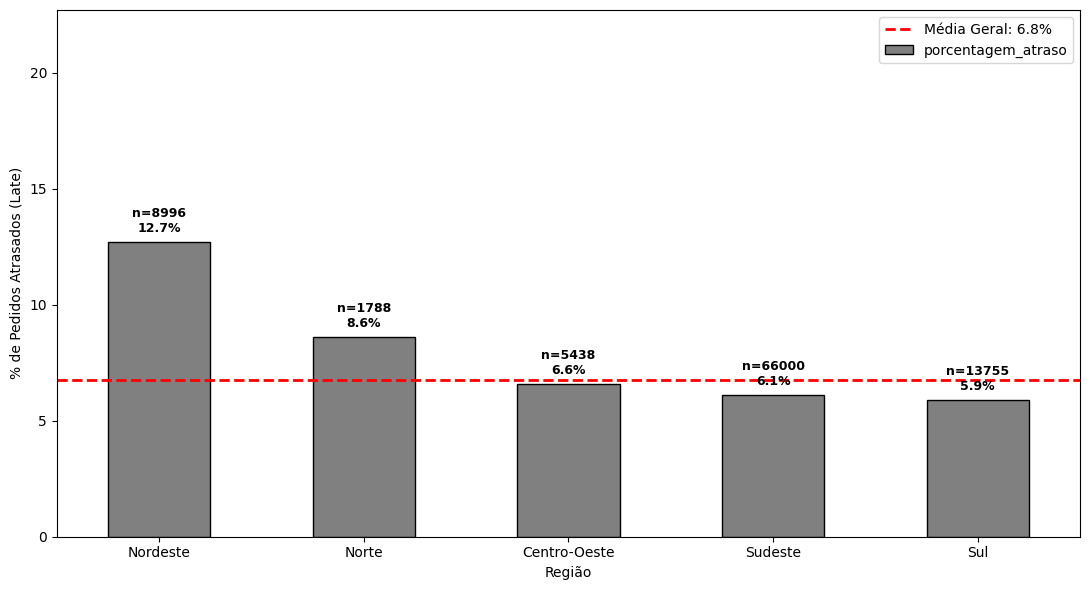

In [59]:
# média geral de atraso
media_geral = (hipotese3['Late'].sum() / hipotese3['total_pedidos'].sum()) * 100

plt.figure(figsize=(11, 6))
ax = hipotese3.set_index('Customer_Region')['porcentagem_atraso'].plot(kind='bar', color='gray', edgecolor='black')

# adicionando a linha da média no gráfico
ax.axhline(media_geral, color='red', linestyle='--', linewidth=2, label=f'Média Geral: {media_geral:.1f}%')

# Personalizando
for i, p in enumerate(ax.patches):
    n_absoluto = hipotese3['total_pedidos'].iloc[i]
    percentual = p.get_height()
    label_texto = f'n={int(n_absoluto)}\n{percentual:.1f}%'
    ax.annotate(label_texto, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 15), textcoords='offset points',
                fontsize=9, fontweight='bold')

# Legendas e Rótluos
plt.legend(loc='upper right')
plt.ylabel('% de Pedidos Atrasados (Late)')
plt.xlabel('Região')
plt.xticks(rotation=0)
plt.ylim(0, hipotese3['porcentagem_atraso'].max() + 10)

plt.tight_layout()
plt.show()

### 4. Atrasos por mês do ano

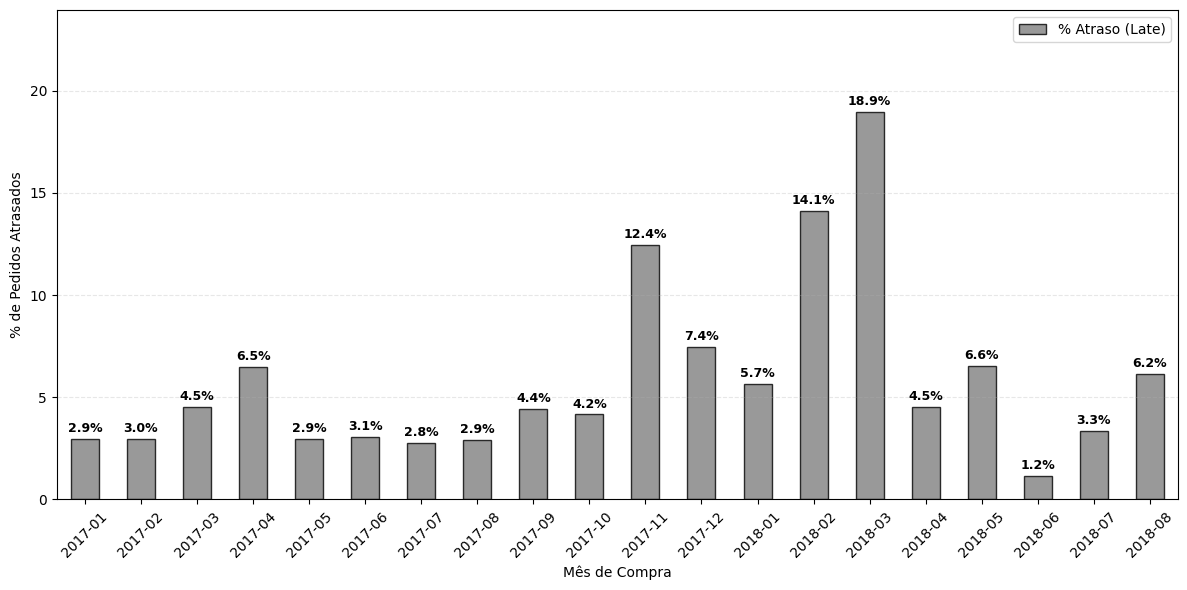

In [60]:
# Preparação dos dados
hipotese4 = orders_delivered[['order_purchase_timestamp', 'delivery_vs_estimated_status']].copy()
hipotese4['mes_ano'] = hipotese4['order_purchase_timestamp'].dt.to_period('M')
evolucao = hipotese4.groupby('mes_ano')['delivery_vs_estimated_status'].value_counts(normalize=True).unstack() * 100
evolucao = evolucao[evolucao.index >= '2017-01']
if 'Late' not in evolucao.columns:
    evolucao['Late'] = 0
plt.figure(figsize=(12, 6))

# Plotando
ax = evolucao['Late'].plot(kind='bar', color='gray', label='% Atraso (Late)', edgecolor='black', alpha=0.8)

# Personalizando
for i, valor in enumerate(evolucao['Late']):
    ax.annotate(f'{valor:.1f}%', # Formatado com 1 casa decimal
                (i, valor),
                textcoords="offset points",
                xytext=(0, 5),
                ha='center',
                fontsize=9,
                fontweight='bold',
    )

plt.ylabel('% de Pedidos Atrasados')
plt.xlabel('Mês de Compra')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.ylim(0, evolucao['Late'].max() + 5)
plt.legend()
plt.tight_layout()
plt.show()

###5. Postagem X Entrega

In [61]:
hipotese5 = orders_delivered[['seller_shipping_days','delivery_vs_estimated_days']]


hipotese5.corr()

,seller_shipping_days,delivery_vs_estimated_days
seller_shipping_days,1.00000,0.26931
delivery_vs_estimated_days,0.26931,1.00000


### 6. Prioridade de ação por região

Text(0.5, 0, 'Região do Cliente')

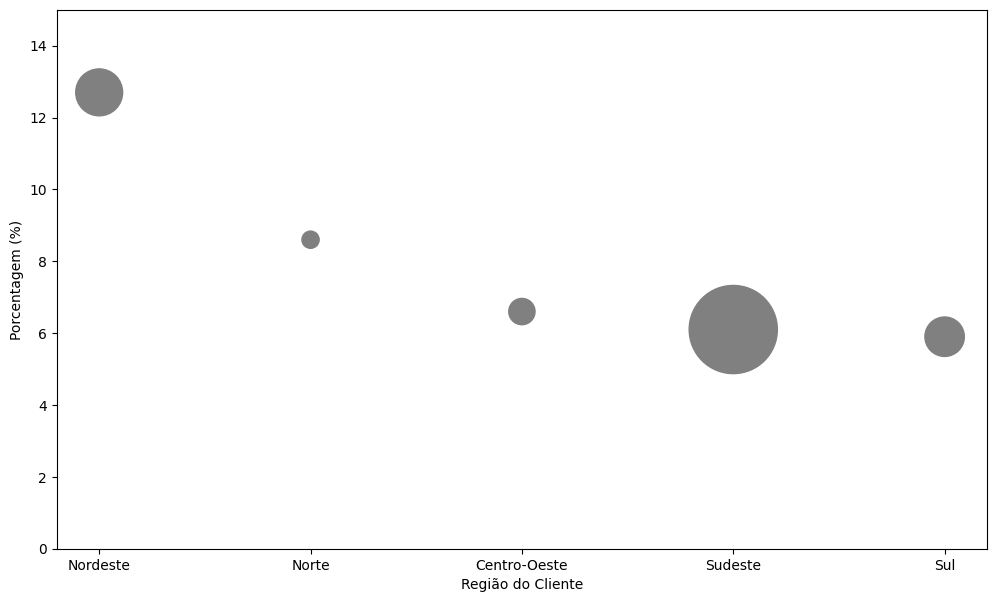

In [62]:
hipotese6 = hipotese3[['Customer_Region','Late','porcentagem_atraso']]

hipotese6.plot(
    kind='scatter',
    x='Customer_Region',
    y='porcentagem_atraso',
    s= hipotese6['Late'],
    color='gray',
    figsize=(12, 7),
    grid=False
)

plt.ylim(0, 15)
plt.ylabel('Porcentagem (%)')
plt.xlabel('Região do Cliente')

###Exportar

In [63]:
orders_delivered.to_csv('orders_delivered.csv', index=False)